In [1]:
#Run in terminal
#pip install medmnist
#pip -m install dlordinal

In [2]:
#Packages
from medmnist import RetinaMNIST
import pandas as pd
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from torch.utils.data import DataLoader
import torch.nn as nn
import dlordinal
from dlordinal.metrics import amae, mmae, accuracy_off1
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier


Dataset RetinaMNIST of size 28 (retinamnist)
    Number of datapoints: 1080
    Root location: C:\Users\tyenc\.medmnist
    Split: train
    Task: ordinal-regression
    Number of channels: 3
    Meaning of labels: {'0': '0', '1': '1', '2': '2', '3': '3', '4': '4'}
    Number of samples: {'train': 1080, 'val': 120, 'test': 400}
    Description: The RetinaMNIST is based on the DeepDRiD challenge, which provides a dataset of 1,600 retina fundus images. The task is ordinal regression for 5-level grading of diabetic retinopathy severity. We split the source training set with a ratio of 9:1 into training and validation set, and use the source validation set as the test set. The source images of 3×1,736×1,824 are center-cropped and resized into 3×28×28.
    License: CC BY 4.0


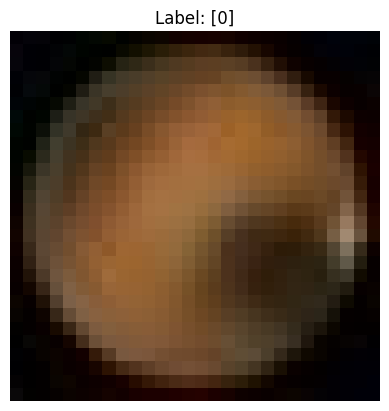


TRAIN split:
  Label 0: 486 images
  Label 1: 128 images
  Label 2: 206 images
  Label 3: 194 images
  Label 4: 66 images

VAL split:
  Label 0: 54 images
  Label 1: 12 images
  Label 2: 28 images
  Label 3: 20 images
  Label 4: 6 images

TEST split:
  Label 0: 174 images
  Label 1: 46 images
  Label 2: 92 images
  Label 3: 68 images
  Label 4: 20 images
total over train, val and test
Label 0: 714 images
Label 1: 186 images
Label 2: 326 images
Label 3: 282 images
Label 4: 92 images


In [3]:
#Loading and preparing the data
train_data = RetinaMNIST(split="train", download=True)
val_data = RetinaMNIST(split="val", download=True)
test_data = RetinaMNIST(split="test", download=True)

train_data_raw = RetinaMNIST(split="train", download=True)
val_data_raw = RetinaMNIST(split="val", download=True)
test_data_raw = RetinaMNIST(split="test", download=True)

print(train_data) #There are 5 labels that classify increasing severity of diabetic retinopathy

#Example of an image
img, label = train_data[0]
plt.imshow(img, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

#Distribution of classifications in data. In each dataset, the distribution of classifications is similar.
splits = ["train", "val", "test"]
all_counts = {}
total_counts = Counter()
for split in splits:
    ds = RetinaMNIST(split=split, download=True)
    labels = [int(ds[i][1].item()) for i in range(len(ds))]
    all_counts[split] = Counter(labels)
    total_counts.update(labels)
for split in splits:
    print(f"\n{split.upper()} split:")
    for label, count in sorted(all_counts[split].items()):
        print(f"  Label {label}: {count} images")
print("total over train, val and test")
for label in sorted(total_counts.keys()):
    print(f"Label {label}: {total_counts[label]} images")


In [10]:
# Select all images from the training set 
all_images = np.stack([np.array(train_data[i][0]) for i in range(len(train_data))])

channel_names = ['R', 'G', 'B']
channel_means = []
channel_stds  = []

# Calculate mean and std for each channel
for c, name in enumerate(channel_names):
    ch = all_images[:, :, :, c]
    channel_means.append(ch.mean())
    channel_stds.append(ch.std())
    # print(f"Channel {name} — mean: {ch.mean():.3f}, std: {ch.std():.3f}")


mean = [channel_means[0]/255, channel_means[1]/255, channel_means[2]/255]
std  = [channel_stds[0]/255, channel_stds[1]/255, channel_stds[2]/255]

print(f"Channel means: {mean}")
print(f"Channel stds: {std}")

# converts image to tensor and scales to [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),      
    transforms.Normalize(mean=mean, std=std)
])

# Apply the transformations to the datasets
train_data = RetinaMNIST(split='train', download=True, transform=transform)
val_data   = RetinaMNIST(split='val',   download=True, transform=transform)
test_data  = RetinaMNIST(split='test',  download=True, transform=transform)

C:\Users\tyenc\AppData\Local\Temp\ipykernel_24812\4198313175.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  all_images = np.stack([np.array(train_data[i][0]) for i in range(len(train_data))])


Channel means: [np.float32(-0.0039968463), np.float32(-0.0029370212), np.float32(-0.002002367)]
Channel stds: [np.float32(0.0019575264), np.float32(0.0028890595), np.float32(0.0034698865)]


LR val accuracy: 0.4833
One-off accuracy: 0.7000
Average mean absolute error (AMAE): 1.1337
Maximum mean absolute error (MMAE): 1.6667

RF val accuracy: 0.4917
One-off accuracy: 0.7917
Average mean absolute error (AMAE): 1.0577
Maximum mean absolute error (MMAE): 1.5000

SVC val accuracy: 0.4500
One-off accuracy: 0.6750
Average mean absolute error (AMAE): 1.2608
Maximum mean absolute error (MMAE): 1.6667

KNN val accuracy: 0.4750
One-off accuracy: 0.7167
Average mean absolute error (AMAE): 1.2917
Maximum mean absolute error (MMAE): 2.3333



c:\Users\tyenc\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


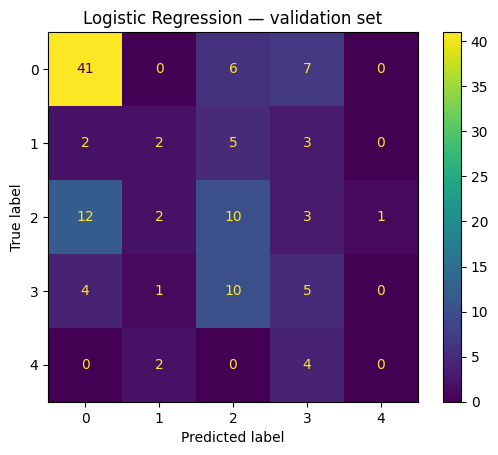

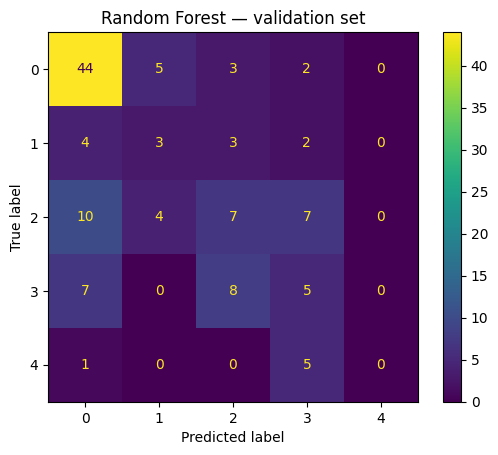

In [9]:
# Baseline model training

# Flatten the images, because sklearn models expects 1D feature vectors, not 2D images
def prepare_sklearn_data(dataset) :
    images = np.stack([np.array(dataset[i][0]) for i in range(len(dataset))])
    labels = np.array([dataset[i][1].item() for i in range(len(dataset))])
    # flatten each image from (28, 28, 3) to (2352)
    images = images.reshape(len(dataset), -1)
    # normalize to [0, 1]
    images = images / 255.0
    return images, labels

# Create new flat datasets with normalized pixel values
X_train, y_train = prepare_sklearn_data(train_data_raw)
X_val,   y_val   = prepare_sklearn_data(val_data_raw)
X_test,  y_test  = prepare_sklearn_data(test_data_raw)

# Train a logistic regression model 
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

lr_val_preds = model.predict(X_val)
lr_val_acc = accuracy_score(y_val, lr_val_preds)
print(f"LR val accuracy: {lr_val_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_val, lr_val_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_val, lr_val_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_val, lr_val_preds):.4f}\n")


# Train a random forest model 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_val_preds = rf_model.predict(X_val)
rf_val_acc = accuracy_score(y_val, rf_val_preds)
print(f"RF val accuracy: {rf_val_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_val, rf_val_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_val, rf_val_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_val, rf_val_preds):.4f}\n")


# Train a linear SVM model 
svc_model = LinearSVC(max_iter=2000, random_state=42)
svc_model.fit(X_train, y_train)

svc_val_preds = svc_model.predict(X_val) 
svc_val_acc = accuracy_score(y_val, svc_val_preds)
print(f"SVC val accuracy: {svc_val_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_val, svc_val_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_val, svc_val_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_val, svc_val_preds):.4f}\n") 


# Train KNN model 
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_val_preds = knn_model.predict(X_val)
knn_val_acc = accuracy_score(y_val, knn_val_preds)
print(f"KNN val accuracy: {knn_val_acc:.4f}")
print(f"One-off accuracy: {accuracy_off1(y_val, knn_val_preds):.4f}")
print(f"Average mean absolute error (AMAE): {amae(y_val, knn_val_preds):.4f}")
print(f"Maximum mean absolute error (MMAE): {mmae(y_val, knn_val_preds):.4f}\n")

# Plot confusion matrix that displays the correct classification of samples predicted for each class (X) vs the true class labels (y)
cm = confusion_matrix(y_val, lr_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("Logistic Regression — validation set")
plt.show()

cm = confusion_matrix(y_val, rf_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("Random Forest — validation set")
plt.show()

In [6]:
# return dataloaders for the RetinaMNIST dataset, given the mean and std for normalization and the batch size.
def get_dataloaders(mean, std, batch_size=32): #  feed 32 images at a time
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    train_data = RetinaMNIST(split='train', download=True, transform=transform)
    val_data   = RetinaMNIST(split='val',   download=True, transform=transform)
    test_data  = RetinaMNIST(split='test',  download=True, transform=transform)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True) # shuffle the training data to help the model generalize better
    val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False) # no need to shuffle validation and test data, because we only evaluate the model on them, not train on them
    test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

# Wrap in Pytorch dataloader objects to enable batching and shuffling
train_loader, val_loader, test_loader = get_dataloaders(mean=mean, std=std)



In [ ]:
# Define CNN model
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3,6,5)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(6,16,5)
        self.fc1 = nn.Linear(16*4*4,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,5)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16*4*4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()

# Define loss function and optimizer (CHOICES)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001) # define optimizer with best learning rate found in test_optimizer.py 

# Model training
epochs = 20 # the amount of passes through the train_loader
min_validation_loss = np.inf # initialises a loss variable for validation loss

for e in range(epochs):
    #Instantiate running loss
    train_loss_epoch = 0.0
    net.train() #Puts model in training mode
    for i, data in enumerate(train_loader, 0):
        train_inputs, train_labels = data
        #Squeezes the image to 1D
        train_labels = train_labels.squeeze().long()
        #Clears the gradients
        optimizer.zero_grad()
        #Runs the forward pass
        train_outputs = net(train_inputs)
        #Finds the loss
        train_loss = criterion(train_outputs, train_labels)
        #Calculates gradients
        train_loss.backward()
        #Updates weights
        optimizer.step()
        #Sums all loss over the epoch and calculates an average loss per batch
        train_loss_epoch += train_loss.item()

    train_loss_epoch /= len(train_loader)
    
    #Model evaluation
    net.eval() # Puts model in evaluation mode
    validation_loss = 0.0 # Instantiates a validation loss
    #Turns off the gradient for evaluation
    with torch.no_grad():
        #For each batch, predict a label and calculate the loss
        for val_inputs, val_labels in val_loader:
            val_labels = val_labels.squeeze().long()
            val_outputs = net(val_inputs)
            val_loss = criterion(val_outputs, val_labels)
            #Sums all loss over the epoch and calculates an average loss per batch
            validation_loss += val_loss.item()
    validation_loss /= len(val_loader)

    #Prints the average training and validation loss of the epoch
    print(f'Epoch {e+1} Training Loss: {train_loss_epoch:.4f} Validation Loss: {validation_loss:.4f}')
    #Saves a model if its validation loss is lower than the currently lowest validation loss
    if min_validation_loss > validation_loss:
        print(f"Validation loss decreased from {min_validation_loss:.4f} to {validation_loss:.4f}. Saving the model")
        min_validation_loss = validation_loss
        torch.save(net.state_dict(), 'saved_model.pth')

Epoch 1 Training Loss: 1.3728 Validation Loss: 1.2284
Validation loss decreased from inf to 1.2284. Saving the model
Epoch 2 Training Loss: 1.2388 Validation Loss: 1.1197
Validation loss decreased from 1.2284 to 1.1197. Saving the model
Epoch 3 Training Loss: 1.2017 Validation Loss: 1.1667
Epoch 4 Training Loss: 1.1906 Validation Loss: 1.1084
Validation loss decreased from 1.1197 to 1.1084. Saving the model
Epoch 5 Training Loss: 1.1640 Validation Loss: 1.1265
Epoch 6 Training Loss: 1.1567 Validation Loss: 1.0828
Validation loss decreased from 1.1084 to 1.0828. Saving the model
Epoch 7 Training Loss: 1.1472 Validation Loss: 1.1074
Epoch 8 Training Loss: 1.1255 Validation Loss: 1.0678
Validation loss decreased from 1.0828 to 1.0678. Saving the model
Epoch 9 Training Loss: 1.1234 Validation Loss: 1.1293
Epoch 10 Training Loss: 1.1195 Validation Loss: 1.0607
Validation loss decreased from 1.0678 to 1.0607. Saving the model
Epoch 11 Training Loss: 1.0918 Validation Loss: 1.0607
Epoch 12 Tr

Test accuracy:            0.5200
Quadratic weighted kappa: 0.4861
One-off accuracy:         0.7575
AMAE:                     1.1554
MMAE:                     2.2500


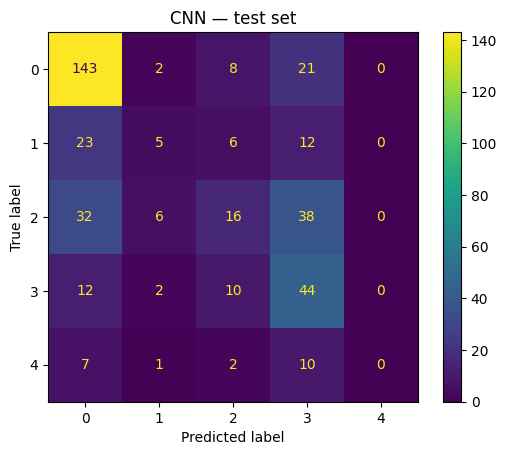

In [8]:
# Evaluation on the test set 

# Load the best saved model
best_model = net
best_model.load_state_dict(torch.load('saved_model.pth'))
best_model.eval()

all_preds  = []
all_labels = []

# turn off the gradient for evaluation, because we don't need to calculate gradients when evaluating the model, and it saves memory and makes it faster
with torch.no_grad():
    # loops through the test set in batches of 32 (set in get_dataloaders) 
    for test_inputs, test_labels in test_loader:
        #Squeezes the image to 1D
        test_labels = test_labels.squeeze().long()
        # Runs the images through the CNN. The output is a tensor of shape (batch_size, num_classes)
        test_outputs = best_model(test_inputs)
        # The predicted class is the one with the highest score. torch.max returns the maximum value and its index 
        _, predicted = torch.max(test_outputs, 1)
        # converting the bartch of predicted labels and true labels from PyTorch tensors to numpy arrays and adds them to the lists
        all_preds.extend(predicted.numpy())
        all_labels.extend(test_labels.numpy())
        # after this loop the lists all_preds and all_labels contain the predictions and true labels for all images in the test set

# Metrics
test_acc   = accuracy_score(all_labels, all_preds)
test_qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
test_off1   = accuracy_off1(all_labels, all_preds)
test_amae   = amae(all_labels, all_preds)
test_mmae   = mmae(all_labels, all_preds)

print(f"Test accuracy:            {test_acc:.4f}")
print(f"Quadratic weighted kappa: {test_qwk:.4f}")
print(f"One-off accuracy:         {test_off1:.4f}")
print(f"AMAE:                     {test_amae:.4f}")
print(f"MMAE:                     {test_mmae:.4f}")

# Plots confusion matrix showing predicted labels (x-axis) against true labels (y-axis)
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot()
plt.title("CNN — test set")
plt.show()     